# CFPB complaint download

Download 1,000 CFPB complaints with non-empty public narratives and save them to `data/raw` as CSV.

In [ ]:
from pathlib import Path
from urllib.request import urlopen
import json

import pandas as pd

API_URL = (
    "https://www.consumerfinance.gov/data-research/consumer-complaints/search/api/v1/"
    "?field=all&has_narrative=true&no_aggs=true&size=1000&sort=created_date_desc"
)

output_path = Path("../data/raw/cfpb_complaints_narratives_1000.csv")

with urlopen(API_URL, timeout=60) as response:
    payload = json.load(response)

records = [hit["_source"] for hit in payload["hits"]["hits"]]
df = pd.DataFrame(records)
df = df[
    df["complaint_what_happened"].notna()
    & df["complaint_what_happened"].astype(str).str.strip().ne("")
].head(1000).copy()

for column in df.columns:
    df[column] = df[column].apply(
        lambda value: json.dumps(value, ensure_ascii=False)
        if isinstance(value, (dict, list))
        else value
    )

output_path.parent.mkdir(parents=True, exist_ok=True)
output_path.write_text(df.to_csv(index=False, lineterminator="\n"), encoding="utf-8")

print(f"Saved {len(df)} complaints to {output_path.resolve()}")


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

print("Setup is working.")

Setup is working.


# 01 — CFPB Complaint Data: Initial EDA

## Purpose

This notebook explores a sample of CFPB consumer complaint narratives.

The goal is to understand:
- Which columns are available
- Which field should be used as the complaint text
- Which field can be used as the classification target
- Whether the data has missing values
- Whether the target classes are imbalanced
- Which fields may support risk and urgency scoring later

This is the first step in building a PII-safe complaint intelligence platform for financial services.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 200)

DATA_PATH = Path("../data/raw/cfpb_complaints_narratives_1000.csv")

df = pd.read_csv(DATA_PATH)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 1000
Columns: 17


,product,complaint_what_happened,date_sent_to_company,issue,sub_product,zip_code,tags,has_narrative,complaint_id,timely,company_response,submitted_via,company,date_received,state,company_public_response,sub_issue
0,Debt collection,"This complaint concerns continued collection efforts relating to a disputed towing/storage deficiency balance allegedly owed to XXXX XXXX XXXX XXXX .\n\nAfter my original CFPB complaint, the colle...",2026-05-21T01:17:04.000Z,Took or threatened to take negative or legal action,Auto debt,90803,NaN,True,22412586,Yes,Closed with explanation,Web,Lien Enforcement Inc,2026-05-21T01:11:23.000Z,CA,Company believes it acted appropriately as authorized by contract or law,Threatened or suggested your credit would be damaged
1,Checking or savings account,"XXXX XXXX, the third-party company responsible for processing and disbursing student refunds on behalf of XXXX University , issued a direct deposit refund in the amount of approximately {$10000.00...",2026-05-21T00:57:25.000Z,Managing an account,Checking account,33181,NaN,True,22412084,Yes,Closed with explanation,Web,WELLS FARGO & COMPANY,2026-05-21T00:33:57.000Z,FL,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Deposits and withdrawals
2,Debt collection,I received a call from XXXX XXXX impersonating an officer of the court with legal XXXX XXXX XXXX documents. They were attempting to come to my residents I contacted Citibank who had no record of d...,2026-05-21T00:42:13.000Z,Took or threatened to take negative or legal action,Credit card debt,377XX,NaN,True,22411686,Yes,Closed with explanation,Web,"CITIBANK, N.A.",2026-05-21T00:26:12.000Z,TN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Threatened or suggested your credit would be damaged
3,Checking or savings account,"XXXX XXXX XXXX XXXX XXXX XXXX XXXX, CA XXXX ( XXXX ) XXXX XXXX Date : XX/XX/XXXX Wells Fargo XXXX Department Re : Request for Reconsideration of Denied Debit Card Fraud Claim Claim Number : XXXX A...",2026-05-20T23:36:29.000Z,Managing an account,Checking account,91342,NaN,True,22409973,Yes,Closed with explanation,Web,WELLS FARGO & COMPANY,2026-05-20T23:25:06.000Z,CA,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Problem using a debit or ATM card
4,Checking or savings account,"XXXX I need you XXXX XXXX, to put it in writing that you state that NO MONEY ( none of my money over the XXXX ) can be withdrawn from my Edge account for the XXXX Days after the NEW MONEY is depo...",2026-05-20T23:31:54.000Z,Managing an account,CD (Certificate of Deposit),XXXXX,Older American,True,22409845,Yes,Closed with explanation,Web,"BANK OF AMERICA, NATIONAL ASSOCIATION",2026-05-20T23:24:35.000Z,CA,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Deposits or withdrawals


In [4]:
column_summary = pd.DataFrame({
    "column_name": df.columns,
    "non_null_count": df.notna().sum().values,
    "missing_count": df.isna().sum().values,
    "missing_percent": (df.isna().mean().values * 100).round(2),
    "dtype": df.dtypes.astype(str).values
})

column_summary

,column_name,non_null_count,missing_count,missing_percent,dtype
0,product,1000,0,0.0,str
1,complaint_what_happened,1000,0,0.0,str
2,date_sent_to_company,1000,0,0.0,str
3,issue,1000,0,0.0,str
4,sub_product,1000,0,0.0,str
5,zip_code,995,5,0.5,str
6,tags,176,824,82.4,str
7,has_narrative,1000,0,0.0,bool
8,complaint_id,1000,0,0.0,int64
9,timely,1000,0,0.0,str


## Column Meaning

- `complaint_what_happened`: Main complaint narrative written by the consumer. This is the primary text input for PII redaction, classification, risk scoring, and RAG.
- `product`: High-level financial product category. This is a strong candidate for the first classification target.
- `issue`: More detailed complaint issue. This can be used later for a harder classification task.
- `sub_product`: More specific product type.
- `sub_issue`: More specific issue type.
- `company`: Financial company involved in the complaint.
- `company_response`: How the company responded.
- `timely`: Whether the company provided a timely response.
- `tags`: Consumer tags such as Older American or Servicemember. Useful for risk/urgency analysis.
- `date_received`: Date the complaint was received.
- `state`: US state of the consumer.

In [5]:
TEXT_COL = "complaint_what_happened"

df[TEXT_COL].head(3)

0    This complaint concerns continued collection efforts relating to a disputed towing/storage deficiency balance allegedly owed to XXXX XXXX XXXX XXXX .\n\nAfter my original CFPB complaint, the colle...
1    XXXX XXXX, the third-party company responsible for processing and disbursing student refunds on behalf of XXXX University , issued a direct deposit refund in the amount of approximately {$10000.00...
2    I received a call from XXXX XXXX impersonating an officer of the court with legal XXXX XXXX XXXX documents. They were attempting to come to my residents I contacted Citibank who had no record of d...
Name: complaint_what_happened, dtype: str

In [6]:
df["text_length_chars"] = df[TEXT_COL].astype(str).str.len()
df["text_length_words"] = df[TEXT_COL].astype(str).str.split().str.len()

df[["text_length_chars", "text_length_words"]].describe()

,text_length_chars,text_length_words
count,1000.000000,1000.000000
mean,1410.181000,232.353000
std,1684.900918,270.866548
min,43.000000,8.000000
25%,495.750000,85.000000
50%,1030.500000,174.000000
75%,1767.000000,290.000000
max,30523.000000,4950.000000


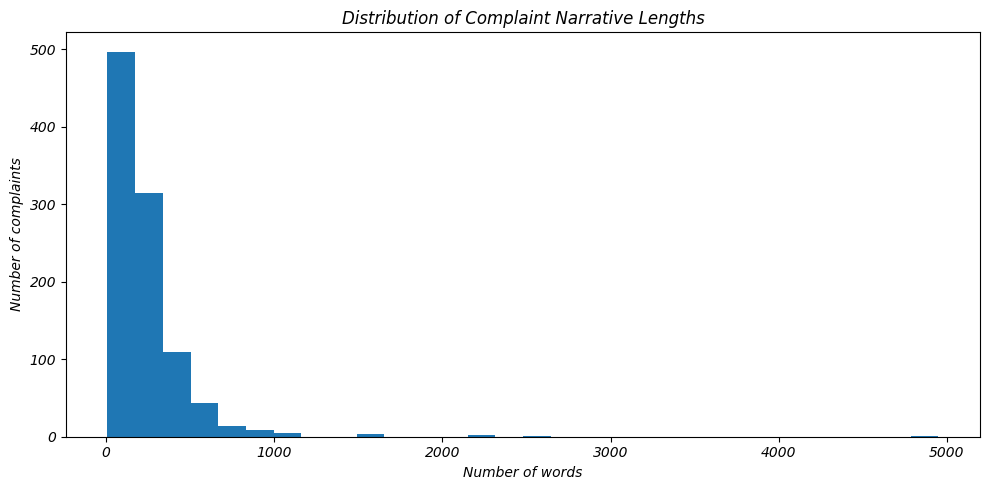

In [7]:
df["text_length_words"].plot(kind="hist", bins=30, figsize=(10, 5), title="Distribution of Complaint Narrative Lengths")

plt.xlabel("Number of words")
plt.ylabel("Number of complaints")
plt.tight_layout()
plt.show()

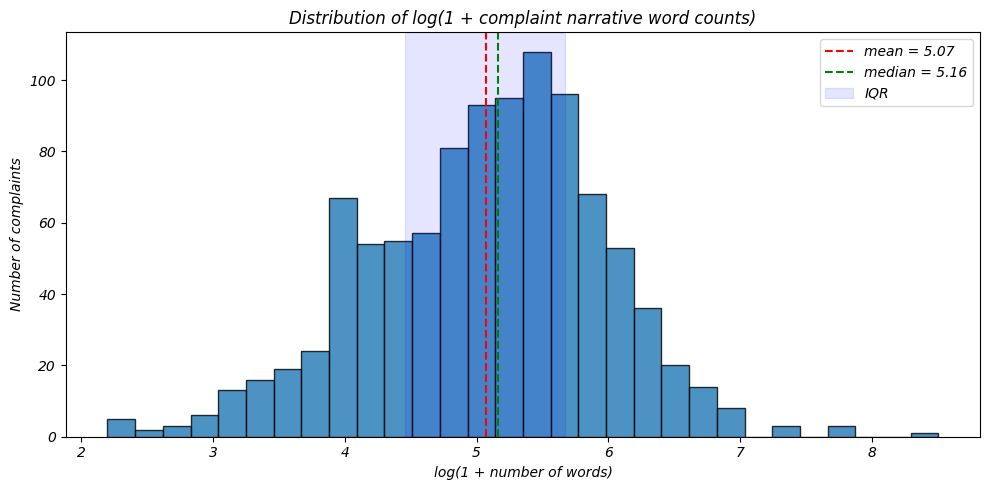

Log length summary:
count    1000.00
mean        5.07
std         0.89
min         2.20
25%         4.45
50%         5.16
75%         5.67
max         8.51
Name: text_length_words, dtype: float64
Concentration approx. between Q1 and Q3: 4.45 - 5.67


In [8]:
# Bu aşağıdaki histogramı plotlayıp çan eğrisinin tam olarak nerede yoğunlaştığını bulalım.
# subplots kullanarak logaritmik dönüşüm uygulayarak daha net bir dağılım görebiliriz.
# q25 ve q75 arasına yoğunlaşma var mı görebiliriz.
# axvline ile mean ve medianı gösterebiliriz.
log_lengths = np.log1p(df["text_length_words"])

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(log_lengths, bins=30, edgecolor="black", alpha=0.8)
ax.set_title("Distribution of log(1 + complaint narrative word counts)")
ax.set_xlabel("log(1 + number of words)")
ax.set_ylabel("Number of complaints")

mean_log = log_lengths.mean()
median_log = log_lengths.median()
q25, q75 = log_lengths.quantile([0.25, 0.75])

ax.axvline(mean_log, color="red", linestyle="--", label=f"mean = {mean_log:.2f}")
ax.axvline(median_log, color="green", linestyle="--", label=f"median = {median_log:.2f}")
ax.axvspan(q25, q75, color="blue", alpha=0.1, label="IQR")

ax.legend()
plt.tight_layout()
plt.show()

print("Log length summary:")
print(log_lengths.describe().round(2))
print(f"Concentration approx. between Q1 and Q3: {q25:.2f} - {q75:.2f}")


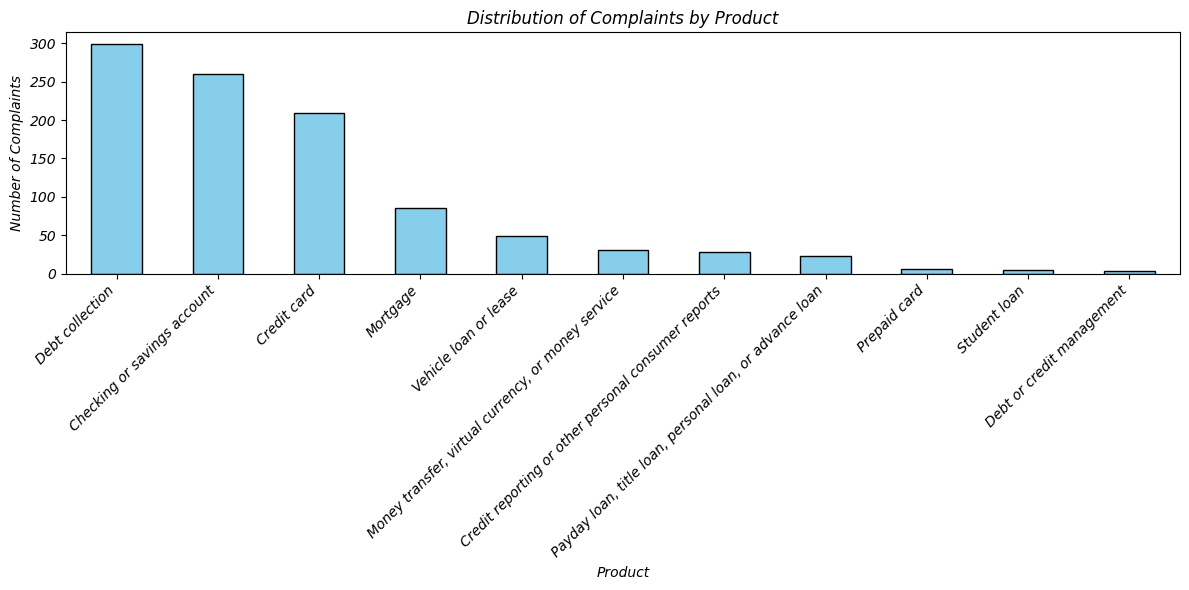

In [10]:
TARGET_COL = "product"

product_counts = df[TARGET_COL].value_counts()

product_counts
# histogram of product distribution
plt.figure(figsize=(12, 6))
product_counts.plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Distribution of Complaints by Product")
plt.xlabel("Product")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [15]:
issue_counts = df["issue"].value_counts()

print("Number of unique issues:", df["issue"].nunique())
issue_counts.head(20)







Number of unique issues: 56


issue
Attempts to collect debt not owed                                  150
Managing an account                                                146
Written notification about debt                                     83
Problem with a purchase shown on your statement                     71
Trouble during payment process                                      38
Closing an account                                                  34
False statements or representation                                  33
Fees or interest                                                    33
Problem with a lender or other company charging your account        32
Struggling to pay mortgage                                          29
Opening an account                                                  23
Getting a credit card                                               23
Problem caused by your funds being low                              22
Closing your account                                                22


In [16]:
df["tags"].value_counts(dropna=False)

tags
NaN                              824
Servicemember                     85
Older American                    78
Older American, Servicemember     13
Name: count, dtype: int64

In [19]:
df["company_response"].value_counts(dropna=False)


company_response
Closed with explanation            855
Closed with non-monetary relief     73
Closed with monetary relief         72
Name: count, dtype: int64

In [20]:
df["timely"].value_counts(dropna=False)

timely
Yes    1000
Name: count, dtype: int64

In [21]:
model_df = df[[TEXT_COL, TARGET_COL]].copy()

model_df = model_df.dropna(subset=[TEXT_COL, TARGET_COL])

model_df = model_df.rename(columns={
    TEXT_COL: "text",
    TARGET_COL: "label"
})

print("Model dataset shape:", model_df.shape)

model_df.head()

Model dataset shape: (1000, 2)


,text,label
0,"This complaint concerns continued collection efforts relating to a disputed towing/storage deficiency balance allegedly owed to XXXX XXXX XXXX XXXX .\n\nAfter my original CFPB complaint, the colle...",Debt collection
1,"XXXX XXXX, the third-party company responsible for processing and disbursing student refunds on behalf of XXXX University , issued a direct deposit refund in the amount of approximately {$10000.00...",Checking or savings account
2,I received a call from XXXX XXXX impersonating an officer of the court with legal XXXX XXXX XXXX documents. They were attempting to come to my residents I contacted Citibank who had no record of d...,Debt collection
3,"XXXX XXXX XXXX XXXX XXXX XXXX XXXX, CA XXXX ( XXXX ) XXXX XXXX Date : XX/XX/XXXX Wells Fargo XXXX Department Re : Request for Reconsideration of Denied Debit Card Fraud Claim Claim Number : XXXX A...",Checking or savings account
4,"XXXX I need you XXXX XXXX, to put it in writing that you state that NO MONEY ( none of my money over the XXXX ) can be withdrawn from my Edge account for the XXXX Days after the NEW MONEY is depo...",Checking or savings account


In [22]:
min_samples_per_class = 20

class_counts = model_df["label"].value_counts()
valid_classes = class_counts[class_counts >= min_samples_per_class].index

model_df_filtered = model_df[model_df["label"].isin(valid_classes)].copy()

print("Original model rows:", len(model_df))
print("Filtered model rows:", len(model_df_filtered))
print("Number of classes kept:", model_df_filtered["label"].nunique())

model_df_filtered["label"].value_counts()

Original model rows: 1000
Filtered model rows: 984
Number of classes kept: 8


label
Debt collection                                            299
Checking or savings account                                260
Credit card                                                209
Mortgage                                                    85
Vehicle loan or lease                                       49
Money transfer, virtual currency, or money service          31
Credit reporting or other personal consumer reports         28
Payday loan, title loan, personal loan, or advance loan     23
Name: count, dtype: int64

In [23]:
PROCESSED_DATA_DIR = Path("../data/processed")
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

output_path = PROCESSED_DATA_DIR / "cfpb_product_classification_sample.csv"

model_df_filtered.to_csv(output_path, index=False)

print("Saved processed model dataset to:", output_path)

Saved processed model dataset to: ../data/processed/cfpb_product_classification_sample.csv
